In [2]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

import os

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Electric_Production.csv to Electric_Production.csv


In [5]:
df = pd.read_csv('Electric_Production.csv')

In [6]:
df.head()

,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


In [9]:
df['Date'] = pd.to_datetime(df['DATE'])
df.set_index('Date', inplace=True)

data = df[['Value']]

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [10]:
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, 30)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [11]:
model_rnn = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(30,1)),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0312
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0145
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0097
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0078
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0065
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 


In [12]:
model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(30,1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1232
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0426
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0161
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0124
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0123
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0126
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0118
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0118
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0119
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0118


In [13]:
model_gru = Sequential([
    GRU(50, activation='relu', input_shape=(30,1)),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1608
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0831
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0315
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0161
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0165
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0159
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0149
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0145
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0144
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0136


In [14]:
pred_lstm = model_lstm.predict(X_test)

# Inverse scaling
pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_actual = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step


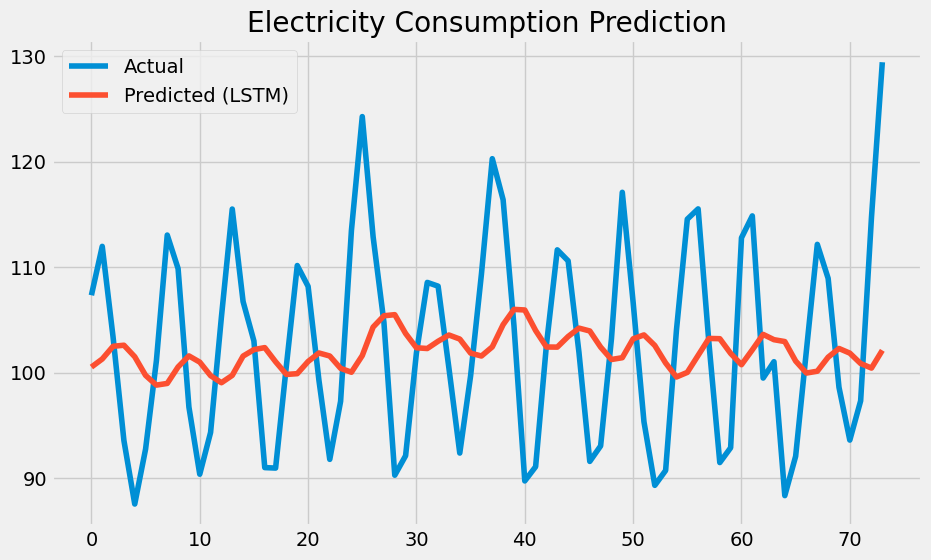

In [15]:
plt.figure(figsize=(10,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred_lstm, label='Predicted (LSTM)')
plt.legend()
plt.title("Electricity Consumption Prediction")
plt.show()

In [16]:
future_steps = 3650  # 10 years (daily data)

last_sequence = X[-1]
predictions = []

for _ in range(future_steps):
    pred = model_lstm.predict(last_sequence.reshape(1,30,1))
    predictions.append(pred[0][0])

    last_sequence = np.append(last_sequence[1:], pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━

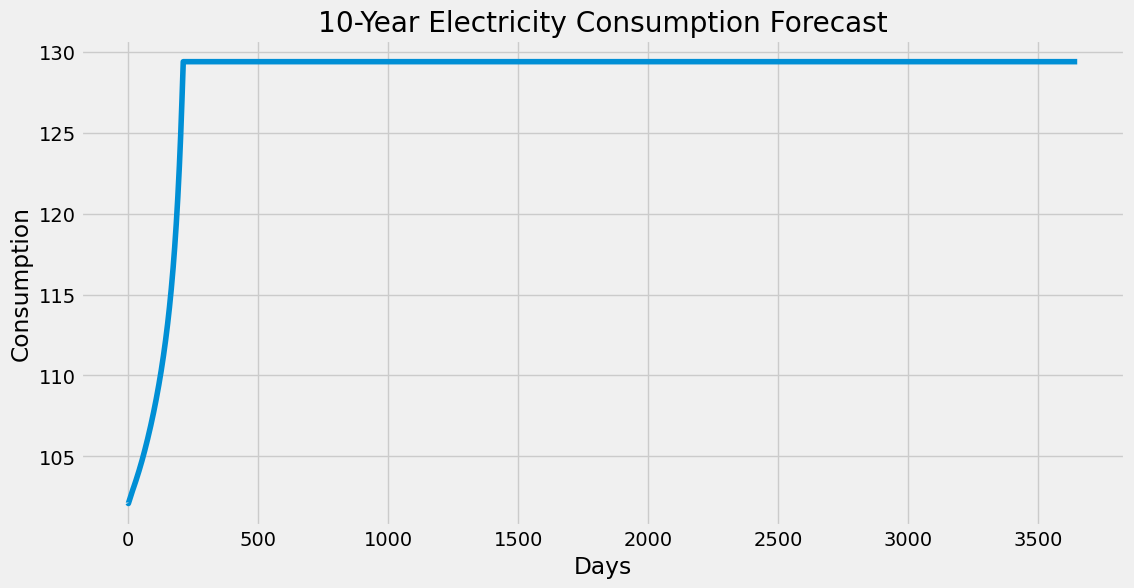

In [19]:
plt.figure(figsize=(12,6))
plt.plot(predictions)
plt.title("10-Year Electricity Consumption Forecast")
plt.xlabel("Days")
plt.ylabel("Consumption")
plt.show()